[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap03/cap03_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

<!-- cap 3 -->

# Operações Espaciais: Transformações Geométricas, Convolução e Morfologia

Objetivos: Aplicar transformações geométricas (rotação, escala, translação); realizar operações de convolução e filtragem; introduzir operações morfológicas (erosão, dilatação, abertura, fechamento).

Conteúdo:

Transformações geométricas (interpolação)

Convolução e filtros (média, gaussiano, bordas)

Morfologia matemática (erosão, dilatação, operações derivadas)



## Objetivos

Ao final deste capítulo, o aluno será capaz de:

- Compreender a representação matemática de imagens $f(x,y)$
- Ler, exibir e salvar imagens
- Trabalhar com imagens binárias, tons de cinza e coloridas (RGB)
- Acessar e modificar pixels individualmente

## O que é uma Imagem Digital?

Uma imagem digital é uma função discreta:

$$f: \mathbb{Z}^2 \rightarrow \mathbb{Z}^k
$$ {#eq-1-imagem}

onde $(x,y)$ são coordenadas espaciais e $f(x,y)$ é a intensidade do pixel.
Para imagens em **tons de cinza** $k=1$ com valores em $[0, 255]$;
para imagens **coloridas** (RGB) $k=3$, ver @fig-1-representacao.


::: {#fig-1-representacao}

![](imagens/lena.jpg){width=70% fig-align="center"}

Exemplo de Transformação Não Linear do Espaço de Entrada para o Espaço de Características.

:::


## Configuração do Ambiente


In [15]:
# Instalação (Google Colab — executar uma vez)
# !pip install opencv-python-headless scikit-image matplotlib numpy

import sys
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, '../../morph')
import morph
importlib.reload(morph)
from morph import mm

print(f'OpenCV {cv2.__version__} | NumPy {np.__version__}')
print("Carregando imagem...")
print(help(mm.show))

OpenCV 4.12.0 | NumPy 2.2.6
Carregando imagem...
Help on function show in module morph:

show(*args, title=None)
    This function will draw images f
    input: <*args> set of images f_i, where i>0 is binary image
          <title> optional string title for the plot
    output: image drawing
    Example:
    f1, f2 = np.zeros((100, 100,3)),  np.zeros((100, 100))
    f2[50:60, 50:60] = 1
    mm.show(f1, f2, title='Exemplo')

None


## 1.3 Lendo e Exibindo Imagens

A operação mais básica em PDI é a leitura de uma imagem.
A função `mm.read()` da `morph.py` aceita caminhos locais e URLs.


Shape  : (512, 512, 3)
Dtype  : uint8
Min/Max: 0 / 255


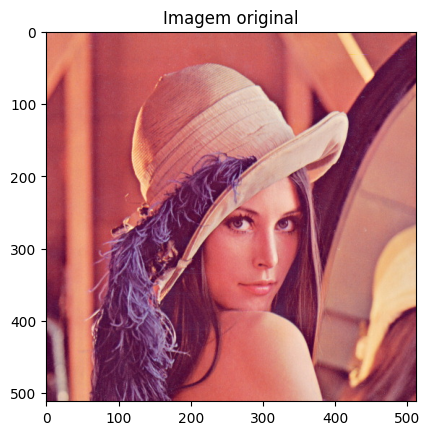

In [ ]:
#| quarto-raw: false
#| label: fig-1-lena
#| fig-cap: "MVS Linear — Margem Máxima entre Íris Setosa e Versicolor (atributos de pétala)."
#| echo: true
#| output: true

import urllib.request, os

# Baixar imagem de exemplo
url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
os.makedirs('imagens', exist_ok=True)
if not os.path.exists('imagens/lena.jpg'):
    urllib.request.urlretrieve(url, 'imagens/lena.jpg')

# Ler imagem com morph.py
img = mm.read('imagens/lena.jpg')

print(f'Shape  : {img.shape}')    # (altura, largura, canais)
print(f'Dtype  : {img.dtype}')    # uint8
print(f'Min/Max: {img.min()} / {img.max()}')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mm.show(img_rgb, title='Imagem original')

## 1.4 Tipos de Imagem

### 1.4.1 Conversão para Tons de Cinza

A conversão de RGB para tons de cinza aplica pesos perceptuais definidos pela ITU-R BT.601:

$$g = 0.299\,R + 0.587\,G + 0.114\,B$$ {#eq-1-cinza}


In [ ]:
# Converter para tons de cinza
img_gray = mm.gray(img)
print(f'Shape cinza: {img_gray.shape}')

mm.show([img, img_gray], title=['Original (RGB)', 'Tons de Cinza'])

### 1.4.2 Limiarização (Binarização)

A limiarização converte uma imagem em tons de cinza para binária:

$$g(x,y) = \begin{cases} 255 & \text{se } f(x,y) \geq T \\ 0 & \text{caso contrário} \end{cases}$$ {#eq-1-limiar}

O método de **Otsu** [@otsu1979] determina $T$ automaticamente maximizando
a variância inter-classes do histograma.


In [ ]:
# Limiarização com T fixo
T = 128
img_bin = mm.threshold(img_gray, T)

# Limiarização Otsu (T automático)
_, img_otsu = cv2.threshold(img_gray, 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'Valores únicos (T={T}): {sorted(set(img_bin.flatten()))}')

mm.show([img_gray, img_bin, img_otsu],
        title=[f'Cinza', f'Binária (T={T})', 'Otsu'])

## 1.5 Acesso a Pixels

Em Python/NumPy, o acesso a pixels usa indexação de arrays `img[linha, coluna]`.


In [ ]:
r, c = 100, 100

# Acessar pixel
pixel_cinza = img_gray[r, c]
pixel_rgb   = img[r, c]       # array [R, G, B]

print(f'Pixel cinza ({r},{c}): {pixel_cinza}')
print(f'Pixel RGB   ({r},{c}): R={pixel_rgb[0]}  G={pixel_rgb[1]}  B={pixel_rgb[2]}')

# Imagem sintética 5×5 com pixel central branco
syn = np.zeros((5, 5), dtype=np.uint8)
syn[2, 2] = 255
print('\nMatriz 5×5:')
print(syn)

## 1.6 Resumo

Neste capítulo foram apresentados os fundamentos de representação de imagens digitais:

- Imagem digital = função $f(x,y)$ mapeando coordenadas para intensidades
- Tipos: binária ($k=1$, $\{0,255\}$), tons de cinza ($k=1$, $[0,255]$), RGB ($k=3$)
- `morph.py`: biblioteca didática que simplifica operações de PDI em Python
- Limiarização: operação fundamental de binarização

O Capítulo 2 estuda **histogramas e equalização**.

### Questões de Revisão

1. Qual a diferença entre imagem em tons de cinza e imagem binária?
2. Como o método de Otsu determina o limiar $T$ automaticamente?
3. O que representa `img.shape` para uma imagem NumPy RGB?

